<a href="https://colab.research.google.com/github/GilangAngga12/pcd/blob/main/pert11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 63.8 MB/s eta 0:00:00


Fraction of zeros in original image: 0.0


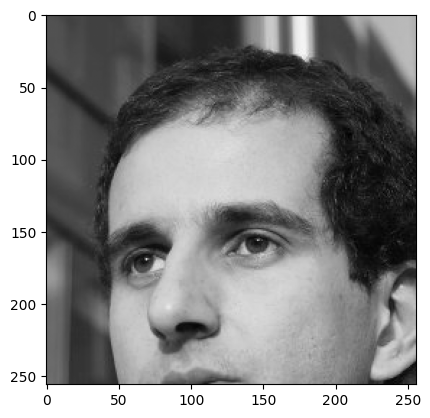

In [ ]:
import numpy as np
import mahotas
import mahotas.demos
from mahotas.thresholding import soft_threshold
from matplotlib import pyplot as plt
from os import path

f = mahotas.demos.load('luispedro',as_grey=True)

f = f[:256,:256]
plt.gray()

#Show the data:
print("Fraction of zeros in original image: {0}".format(np.mean(f==0)))

plt.imshow(f)
plt.show()

Kode ini berfungsi untuk memuat gambar grayscale 'luispedro' menggunakan library mahotas, kemudian memotongnya menjadi ukuran 256x256 piksel. Setelah itu, kode ini mencetak proporsi piksel bernilai nol dalam gambar yang dipotong dan menampilkannya menggunakan matplotlib dengan skema warna grayscale.

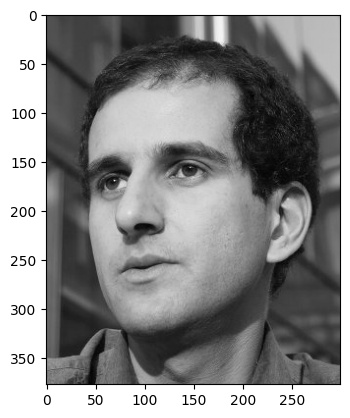

In [ ]:
import mahotas
import mahotas.demos
import numpy as np
from pylab import imshow, gray, show
from os import path

photo = mahotas.demos.load('luispedro',as_grey=True)
photo = photo.astype(np.uint8)
gray()

imshow(photo)
show()

Kode ini memuat gambar, mengonversinya ke skala abu-abu dan tipe float jika diperlukan, kemudian menerapkan algoritma segmentasi Chan-Vese untuk memisahkan objek dari latar belakang. Hasil segmentasi, level set akhir, dan grafik evolusi energi selama proses segmentasi, ditampilkan dalam empat sub-plot menggunakan Matplotlib untuk visualisasi.

116


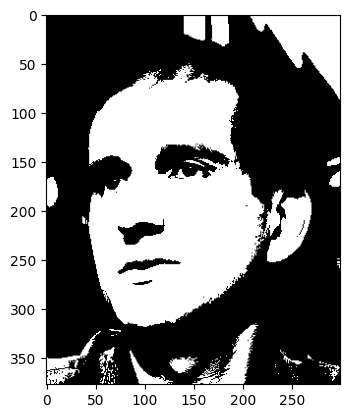

In [ ]:
T_otsu = mahotas.otsu(photo)
print(T_otsu)
imshow(photo>T_otsu)
show()

Kode ini berfungsi untuk menghitung nilai ambang batas (threshold) Otsu secara otomatis dari gambar photo yang sudah ada, kemudian mencetak nilai threshold tersebut. Selanjutnya, kode ini menerapkan thresholding Otsu untuk membuat gambar biner, di mana piksel yang lebih terang dari nilai ambang batas menjadi putih dan yang lebih gelap menjadi hitam, lalu menampilkan hasilnya.

116


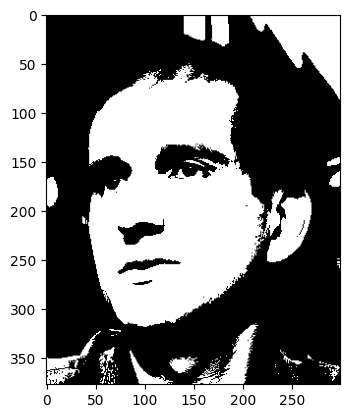

In [ ]:
import mahotas
import mahotas.demos
import numpy as np
from pylab import imshow, gray, show
from os import path

photo = mahotas.demos.load('luispedro',as_grey=True)
photo = photo.astype(np.uint8)
T_otsu = mahotas.otsu(photo)

print(T_otsu)
gray()

imshow(photo > T_otsu)
show()

Kode ini memuat gambar 'luispedro' sebagai grayscale menggunakan mahotas, mengonversinya ke tipe uint8, lalu secara otomatis menghitung dan mencetak nilai ambang batas Otsu (T_otsu). Selanjutnya, kode ini menerapkan nilai T_otsu untuk mengonversi gambar menjadi biner (piksel di atas ambang batas menjadi putih, lainnya hitam), dan kemudian menampilkan gambar biner hasil thresholding tersebut.

115.94160041170963


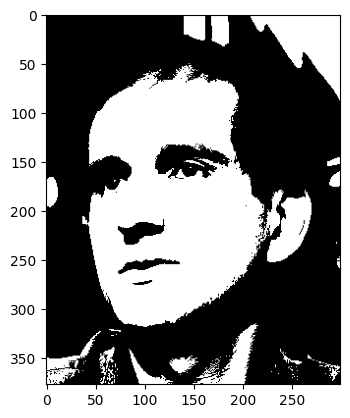

In [ ]:
T_rc = mahotas.rc(photo)
print(T_rc)
imshow(photo > T_rc)
show()

Kode ini melakukan thresholding pada sebuah gambar (yang sebelumnya disimpan dalam variabel photo) menggunakan metode ambang batas RC (Riddler-Calvard atau kadang disebut juga Huang) dan kemudian menampilkan hasilnya.

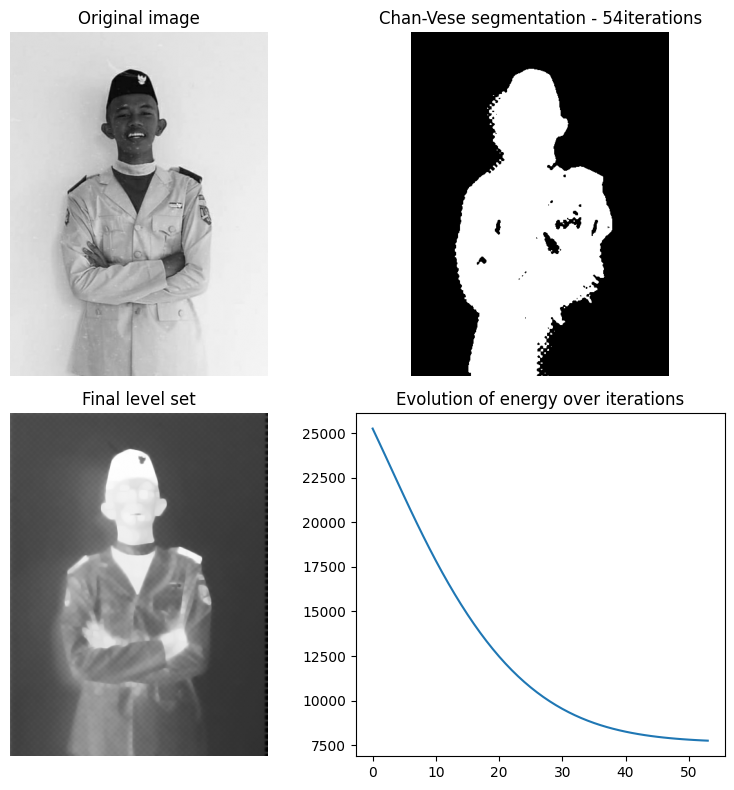

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import data, img_as_float
from skimage.segmentation import chan_vese
from skimage.color import rgb2gray # Import rgb2gray

#Ganti 'path/to/your/image.jpg' dengan path (lokasi) file gambar Anda
image_path = '/content/823becd4-828c-435d-9e12-a83ef834d3a8.jfif'
image = mpimg.imread(image_path)

# Konversi gambar ke grayscale jika gambar adalah RGB (3D)
if image.ndim == 3:
    image = rgb2gray(image)

image = img_as_float(image) # Pastikan gambar dalam format float

#Feel free to play arround with the parameters
#to see how they impact the result

cv = chan_vese(image, mu=0.25, lambda1=1, lambda2=1, tol=1e-3, max_num_iter=200,
               dt=0.5, init_level_set="checkerboard",
               extended_output=True)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
ax = axes.flatten()
ax[0].imshow(image, cmap="gray")
ax[0].set_axis_off()
ax[0].set_title("Original image", fontsize=12)
ax[1].imshow(cv[0], cmap="gray")
ax[1].set_axis_off()

title = "Chan-Vese segmentation - {}iterations".format(len(cv[2]))
ax[1].set_title(title, fontsize=12)
ax[2].imshow(cv[1], cmap="gray")
ax[2].set_axis_off()
ax[2].set_title("Final level set", fontsize=12)
ax[3].plot(cv[2])
ax[3].set_title("Evolution of energy over iterations", fontsize=12)
fig.tight_layout()
plt.show()